In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
%cd drive/MyDrive/Cs412/project_files

/content/drive/MyDrive/Cs412/project_files


In [ ]:
%ls

 bugs-test.csv                            results/
 bugs-train.csv                           rf_bert_predictions_10.csv
 count_vectorizer_4gram200.pkl            rf_bert_predictions_11.csv
 encoded_texts_512.pkl                    rf_bert_predictions_2.csv
 encoded_texts.pkl                        rf_bert_predictions_3.csv
 encoded_texts_train_test_128.pkl         rf_bert_predictions_4.csv
 encoded_texts_train_test_1.pkl           rf_bert_predictions_5.csv
 encoded_texts_train_test_512.pkl         rf_bert_predictions_6.csv
 encoded_texts_train_test.pkl             rf_bert_predictions_7.csv
 lgbm_p-_sm-.ipynb                        rf_bert_predictions_8.csv
 ngram_vectorizer.pkl                     rf_bert_predictions_9.csv
'predictions_02 06 2024_02_49.csv'       'submission_02 06 2024.csv'
 predictions.csv                          submission_0_51.csv
 random_forest_max.joblib                 submission_0_55.csv
 randomforest_predictions_2.csv           submission.csv
 random_forest_sm

In [ ]:
!pip install imblearn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 258.3/258.3 kB 2.3 MB/s eta 0:00:00


In [ ]:
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from transformers import BertTokenizer, BertModel
import torch
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import make_scorer, precision_score, classification_report
from imblearn.over_sampling import SMOTE
import joblib
import traceback
import numpy as np
from scipy.sparse import isspmatrix, csr_matrix
import pickle
import joblib
from sklearn.metrics import make_scorer, precision_score, classification_report, roc_auc_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_curve, average_precision_score

In [ ]:
data = pd.read_csv('bugs-train.csv')
# Load test data
test_data = pd.read_csv('bugs-test.csv')
# Severity mapping
severity_mapping = {
    'trivial': 0,
    'enhancement': 1,
    'minor': 2,
    'normal': 3,
    'major': 4,
    'blocker': 5,
    'critical': 6
}
# Map severity values to integers
data['severity'] = data['severity'].map(severity_mapping)


In [ ]:
# Display the first few rows of the training dataset
print("First few rows of the training dataset:")
print(data.head())

# Check for class imbalance in the training set
severity_counts = data['severity'].value_counts()
print("\nDistribution of Bug Severity in Training Set:")
print(severity_counts)

First few rows of the training dataset:
   bug_id                                            summary  severity
0  365569                  Remove workaround from bug 297227         3
1  365578    Print Preview crashes on any URL in gtk2 builds         6
2  365582                     Lines are not showing in table         4
3  365584  Firefox render ÛÏsimplified ArabicÛ font fa...         3
4  365597             Crash [@ nsINodeInfo::NodeInfoManager]         6

Distribution of Bug Severity in Training Set:
severity
3    125854
6     18658
4      6053
1      4426
2      3102
0      1204
5       701
Name: count, dtype: int64


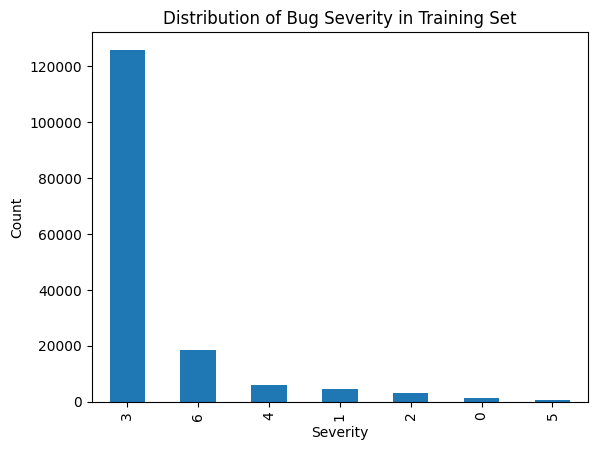

In [ ]:
# Plot the distribution of bug severity in the training set
severity_counts.plot(kind='bar')
plt.xlabel('Severity')
plt.ylabel('Count')
plt.title('Distribution of Bug Severity in Training Set')
plt.show()

In [ ]:
# Extract features using BERT
X = data['summary'].tolist()
y = data['severity'].values
X_test = test_data['summary'].tolist()

# Initialize BERT tokenizer and model
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')

# Tokenize and encode the text data in batches to manage memory usage
def batch_encode_texts(texts, batch_size=64):
    embeddings = []
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i + batch_size]
        encoded_input = tokenizer(batch_texts, padding=True, truncation=True, return_tensors='pt', max_length=512)
        with torch.no_grad():
            model_output = model(**encoded_input)
        batch_embeddings = model_output.last_hidden_state[:, 0, :].numpy()
        embeddings.append(batch_embeddings)
        print( f"Completed batch {i // batch_size + 1}/{len(texts) // batch_size + 1}")
    return np.vstack(embeddings)

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

In [ ]:
# Tokenizing and encoding training data
X_encoded = batch_encode_texts(X)

Completed batch 1/2500
Completed batch 2/2500
Completed batch 3/2500
Completed batch 4/2500
Completed batch 5/2500
Completed batch 6/2500
Completed batch 7/2500
Completed batch 8/2500
Completed batch 9/2500
Completed batch 10/2500
Completed batch 11/2500
Completed batch 12/2500
Completed batch 13/2500
Completed batch 14/2500
Completed batch 15/2500
Completed batch 16/2500
Completed batch 17/2500
Completed batch 18/2500
Completed batch 19/2500
Completed batch 20/2500
Completed batch 21/2500
Completed batch 22/2500
Completed batch 23/2500
Completed batch 24/2500
Completed batch 25/2500
Completed batch 26/2500
Completed batch 27/2500
Completed batch 28/2500
Completed batch 29/2500
Completed batch 30/2500
Completed batch 31/2500
Completed batch 32/2500
Completed batch 33/2500
Completed batch 34/2500
Completed batch 35/2500
Completed batch 36/2500
Completed batch 37/2500
Completed batch 38/2500
Completed batch 39/2500
Completed batch 40/2500
Completed batch 41/2500
Completed batch 42/2500
C

In [ ]:
# Tokenizing and encoding test data
X_test_encoded = batch_encode_texts(X_test)

Completed batch 1/1346
Completed batch 2/1346
Completed batch 3/1346
Completed batch 4/1346
Completed batch 5/1346
Completed batch 6/1346
Completed batch 7/1346
Completed batch 8/1346
Completed batch 9/1346
Completed batch 10/1346
Completed batch 11/1346
Completed batch 12/1346
Completed batch 13/1346
Completed batch 14/1346
Completed batch 15/1346
Completed batch 16/1346
Completed batch 17/1346
Completed batch 18/1346
Completed batch 19/1346
Completed batch 20/1346
Completed batch 21/1346
Completed batch 22/1346
Completed batch 23/1346
Completed batch 24/1346
Completed batch 25/1346
Completed batch 26/1346
Completed batch 27/1346
Completed batch 28/1346
Completed batch 29/1346
Completed batch 30/1346
Completed batch 31/1346
Completed batch 32/1346
Completed batch 33/1346
Completed batch 34/1346
Completed batch 35/1346
Completed batch 36/1346
Completed batch 37/1346
Completed batch 38/1346
Completed batch 39/1346
Completed batch 40/1346
Completed batch 41/1346
Completed batch 42/1346
C

## Save/Load Tokenized Data


In [ ]:
# Save encoded texts and labels
with open('encoded_texts_train_test_512.pkl', 'wb') as f:
    pickle.dump((X_encoded, y, X_test_encoded), f)

In [ ]:
# Load encoded texts and labels (for future use)
with open('encoded_texts_train_test_512.pkl', 'rb') as f:
    X_encoded, y, X_test_encoded = pickle.load(f)

In [ ]:
print(X_test_encoded.shape)

(86094, 768)


## Grid Search for Best Hyperparameters with Random Forest


In [ ]:
from sklearn.model_selection import ParameterGrid
# Define the parameter grid for Random Forest
param_grid = {
    'n_estimators': [100, 200, 300],
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Define SMOTE
smote = SMOTE(sampling_strategy={
    0: 7000,  # trivial
    1: 15000,  # enhancement
    2: 10000,  # minor
    4: 20000,  # major
    5: 5000,   # blocker
    6: 50000  # critical
}, random_state=42)

# Apply Stratified K-Fold Cross Validation
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
best_score = 0
best_params = None

# Scoring method
scorer = make_scorer(precision_score, average='macro')

try:
    for params in ParameterGrid(param_grid):
        print(f"Testing parameters: {params}")
        scores = []

        # Initialize the Random Forest classifier with current parameters
        clf = RandomForestClassifier(**params, verbose=2, n_jobs=-1, random_state=42)

        for train_index, test_index in skf.split(X_encoded, y):
            X_train, X_test = X_encoded[train_index], X_encoded[test_index]
            y_train, y_test = y[train_index], y[test_index]

            X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

            clf.fit(X_train_res, y_train_res)
            y_pred = clf.predict(X_test)

            score = precision_score(y_test, y_pred, average='macro')
            scores.append(score)
            print(f"Fold score: {score}")

            # Print classification report for this fold
            print(classification_report(y_test, y_pred))

        avg_score = np.mean(scores)
        print(f"Average Macro Precision for current parameters: {avg_score}")

        if avg_score > best_score:
            best_score = avg_score
            best_params = params

    print(f"Best Parameters: {best_params}")
    print(f"Best Macro Precision Score: {best_score}")

except Exception as e:
    print(f"Error evaluating Random Forest: {e}")
    traceback.print_exc()


# Testing Best Hyperparameters on Training Data






In [ ]:
# Apply SMOTE to increase data points for specified classes

smote = SMOTE(sampling_strategy={
    0: 7000,  # trivial
    1: 15000,  # enhancement
    2: 10000,  # minor
    4: 20000,  # major
    5: 5000,   # blocker
    6 : 50000  # critical
}, random_state=42)

# Apply Stratified K-Fold Cross Validation
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
scores = []

# Initialize the Random Forest classifier
clf = RandomForestClassifier( n_jobs=-1, n_estimators=300, criterion="gini", max_depth=None, min_samples_leaf=2,min_samples_split=10)

# Scoring method
scorer = make_scorer(precision_score, average='macro')

try:
    i = 0
    for train_index, test_index in skf.split(X_encoded, y):

        X_train, X_test = X_encoded[train_index], X_encoded[test_index]
        y_train, y_test = y[train_index], y[test_index]

        X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

        clf.fit(X_train_res, y_train_res)
        y_pred = clf.predict(X_test)
        y_pred_prob = clf.predict_proba(X_test)  # for ROC curve

        score = precision_score(y_test, y_pred, average='macro')
        scores.append(score)
        print(f"Fold score: {score}")

        # Print classification report for this fold
        print(classification_report(y_test, y_pred))
         # Save y_test and y_pred for plots
        i = i+1
        np.save(f'y_test_fold_{i}.npy', y_test)
        np.save(f'y_pred_fold_{i}.npy', y_pred)
        np.save(f'y_pred_prob_fold_{i}.npy', y_pred_prob)


    print(f"Random Forest Macro Precision: {np.mean(scores)}")

except Exception as e:
    print(f"Error evaluating Random Forest: {e}")
    traceback.print_exc()

Fold score: 0.6973473079824885
              precision    recall  f1-score   support

           0       0.40      0.00      0.01       401
           1       0.59      0.02      0.03      1475
           2       0.50      0.00      0.01      1034
           3       0.86      0.98      0.91     41952
           4       0.75      0.04      0.08      2018
           5       1.00      0.01      0.02       234
           6       0.79      0.67      0.73      6219

    accuracy                           0.85     53333
   macro avg       0.70      0.25      0.25     53333
weighted avg       0.83      0.85      0.81     53333

Fold score: 0.7086464057792696
              precision    recall  f1-score   support

           0       0.71      0.01      0.02       402
           1       0.66      0.02      0.03      1476
           2       0.42      0.00      0.01      1034
           3       0.86      0.98      0.91     41951
           4       0.72      0.04      0.08      2017
           5    

# Visualizations

## Confusion Matrix

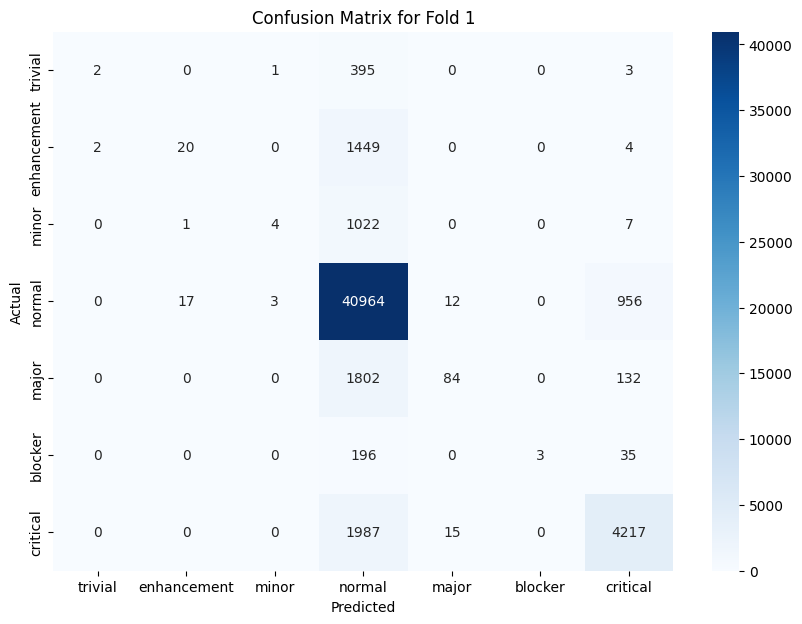

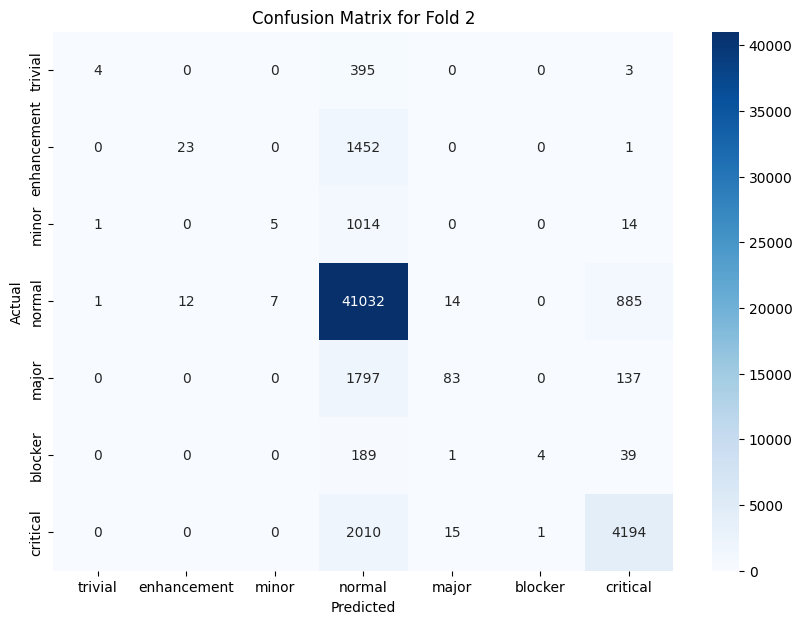

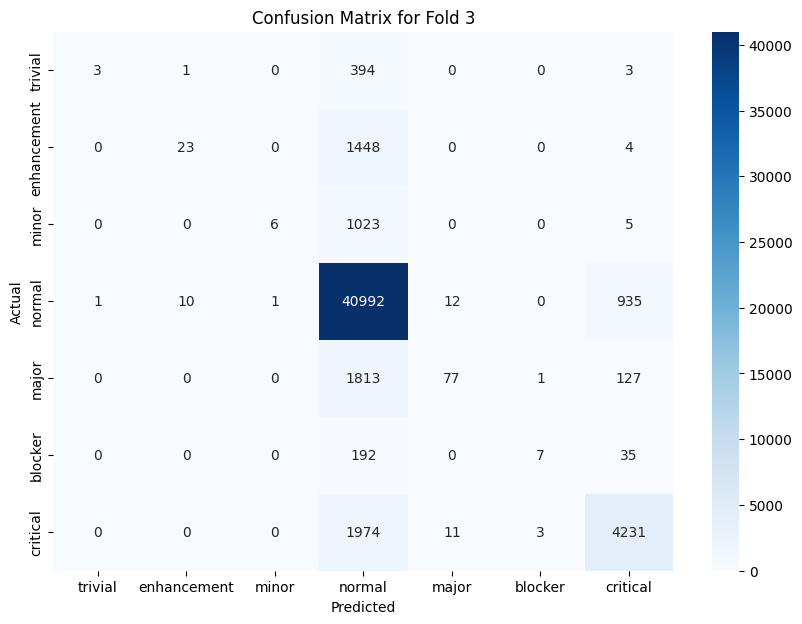

In [ ]:
for fold in range(3):
    y_test = np.load(f'y_test_fold_{fold+1}.npy')
    y_pred = np.load(f'y_pred_fold_{fold+1}.npy')

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=severity_mapping.keys(), yticklabels=severity_mapping.keys())
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix for Fold {fold+1}')
    plt.show()

##ROC Curve

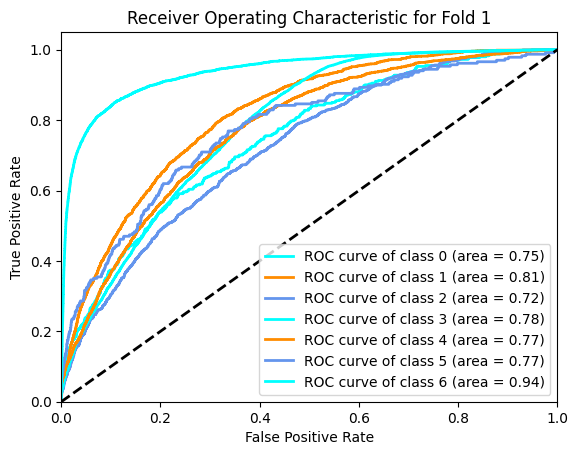

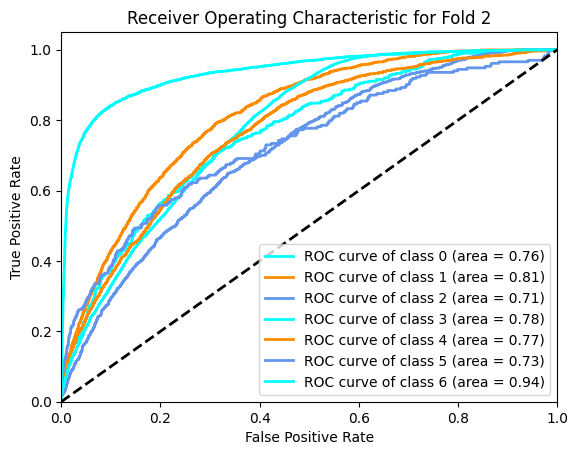

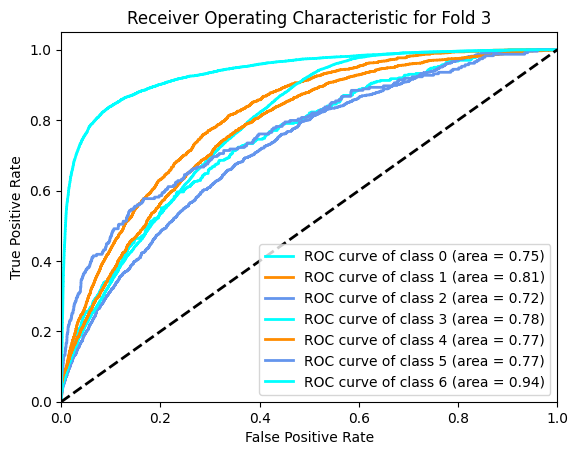

In [ ]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from itertools import cycle

for fold in range(3):
    y_test = np.load(f'y_test_fold_{fold+1}.npy')
    y_pred_prob = np.load(f'y_pred_prob_fold_{fold+1}.npy')

    n_classes = len(severity_mapping)
    y_test_bin = label_binarize(y_test, classes=range(n_classes))

    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Plot all ROC curves
    plt.figure()
    colors = cycle(['aqua', 'darkorange', 'cornflowerblue'])
    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label=f'ROC curve of class {i} (area = {roc_auc[i]:0.2f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Receiver Operating Characteristic for Fold {fold+1}')
    plt.legend(loc="lower right")
    plt.show()

##Precision-Recall Curve

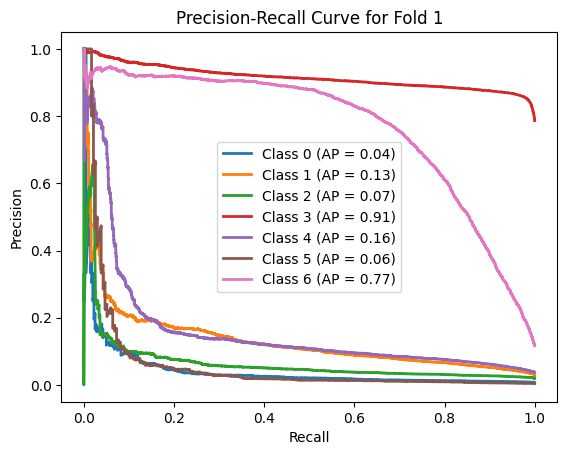

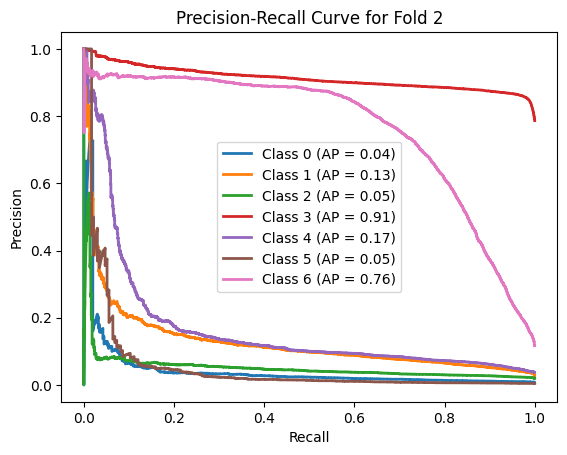

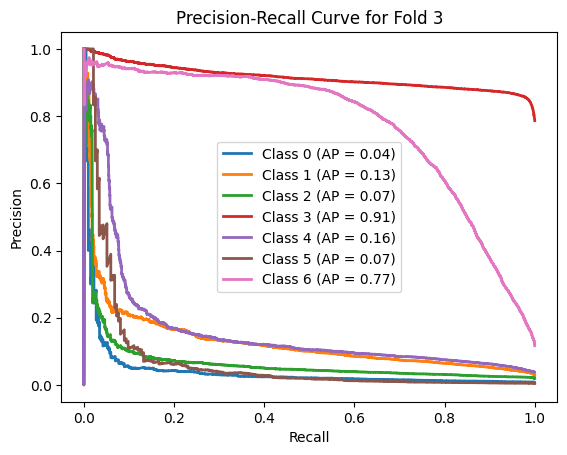

In [ ]:
for fold in range(3):
    y_test = np.load(f'y_test_fold_{fold+1}.npy')
    y_pred_prob = np.load(f'y_pred_prob_fold_{fold+1}.npy')

    # Binarize the output
    y_test_bin = label_binarize(y_test, classes=range(n_classes))

    plt.figure()
    for i in range(n_classes):
        precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_pred_prob[:, i])
        average_precision = average_precision_score(y_test_bin[:, i], y_pred_prob[:, i])
        plt.plot(recall, precision, lw=2, label=f'Class {i} (AP = {average_precision:0.2f})')

    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curve for Fold {fold+1}')
    plt.legend(loc="best")
    plt.show()


#Training Best Model on the Entire Training Dataset

In [ ]:
 # Save the best model for future use
model_filename = f'random_forest_max.joblib'
joblib.dump(clf, model_filename)

['random_forest_max.joblib']

In [ ]:
# Train on the entire dataset
try:
    X_train_res, y_train_res = smote.fit_resample(X_encoded, y)
    clf.fit(X_train_res, y_train_res)
except Exception as e:
    print(f"Error training Random Forest on the entire dataset: {e}")
    traceback.print_exc()

# Make predictions on the test dataset
try:
    test_predictions = clf.predict(X_test_encoded)
except Exception as e:
    print(f"Error making predictions on the test dataset: {e}")
    traceback.print_exc()

# Making Predictions on the Test Dataset


In [ ]:
# Load the model
clf = joblib.load('random_forest_max.joblib')

In [ ]:
# Make predictions on the test dataset
test_predictions = clf.predict(X_test_encoded)

# Inverse mapping
inverse_severity_mapping = {v: k for k, v in severity_mapping.items()}
test_data['severity_mapped'] = test_predictions
test_data['severity'] = test_data['severity_mapped'].map(inverse_severity_mapping)

# Save the test predictions
test_data.rename(columns={"bug id": "bug_id"}, inplace=True)
output_data = test_data[['bug_id', 'severity']]
output_file_path = 'rf_bert_predictions_6.csv'
output_data.to_csv(output_file_path, index=False)

[Parallel(n_jobs=96)]: Using backend ThreadingBackend with 96 concurrent workers.
[Parallel(n_jobs=96)]: Done 110 out of 200 | elapsed:    0.6s remaining:    0.5s
[Parallel(n_jobs=96)]: Done 200 out of 200 | elapsed:    0.7s finished
